In [2]:
from google.colab import files
uploded = files.upload()

Saving Iris.csv to Iris (1).csv


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
accuracy_score,
confusion_matrix,
classification_report,
ConfusionMatrixDisplay
)

In [4]:
df = pd.read_csv("Iris.csv")

In [5]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [8]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [9]:
print(df.duplicated().sum())

0


In [10]:
df = df.drop("Id", axis=1)

In [11]:
print(df["Species"].value_counts())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [12]:
encoder = LabelEncoder()
df["Species"] = encoder.fit_transform(df["Species"])
print("\nEncoded Class")
for i,name in enumerate(encoder.classes_):
  print(i,"=",name)


Encoded Class
0 = Iris-setosa
1 = Iris-versicolor
2 = Iris-virginica


In [13]:
X = df.drop("Species",axis=1)
y = df["Species"]

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(120, 4)
(30, 4)
(120,)
(30,)


In [16]:
model = LogisticRegression(max_iter=700)
model.fit(X_train,y_train)

LogisticRegression(max_iter=700)

In [17]:
y_pred = model.predict(X_test)

In [18]:
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy : {accuracy*100:.2f}%")

Accuracy : 100.00%


In [23]:
print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))


Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [21]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


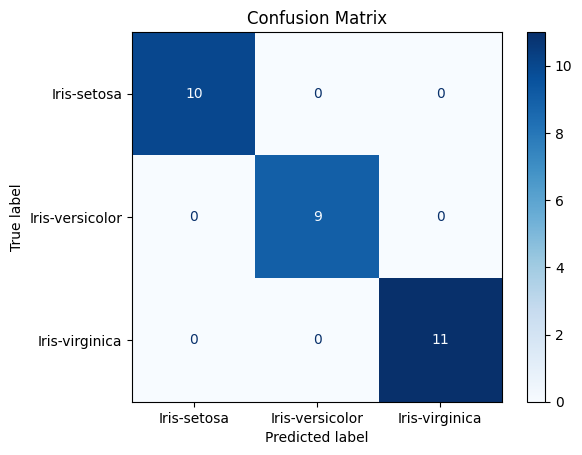

In [22]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [24]:
importance = np.mean(np.abs(model.coef_), axis=0)

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)


print("FEATURE IMPORTANCE")


print(importance_df)

FEATURE IMPORTANCE
         Feature  Importance
2  PetalLengthCm    1.727229
3   PetalWidthCm    1.183700
1   SepalWidthCm    0.634929
0  SepalLengthCm    0.341477


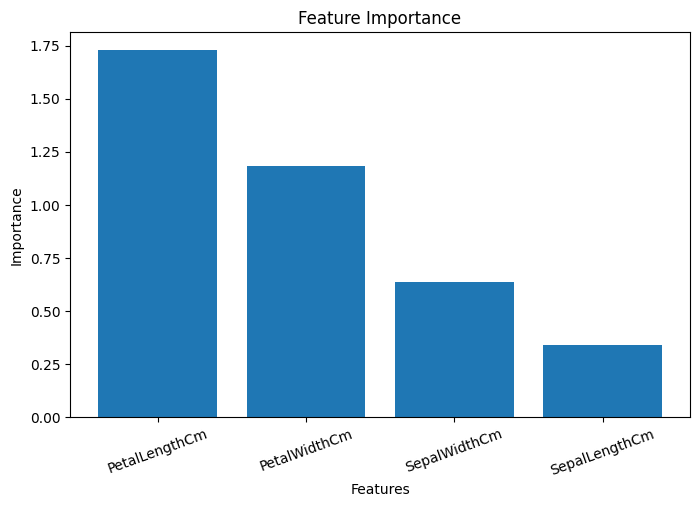

In [25]:
plt.figure(figsize=(8,5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.xticks(rotation=20)

plt.show()


In [28]:
print("NEW FLOWER PREDICTION")


new_flower_data = [[5.1, 3.5, 1.4, 0.2]] # Removed dummy 'Id'
# Convert to DataFrame with feature names for consistent input
new_flower = pd.DataFrame(new_flower_data, columns=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'])

prediction = model.predict(new_flower)

# The model already predicts string labels, so inverse_transform is not needed and causes an error due to encoder's state.
flower = encoder.inverse_transform(prediction)

print("Predicted Flower Species :", flower[0])

NEW FLOWER PREDICTION
Predicted Flower Species : Iris-setosa


In [33]:
flowers_data = [
    [5.1,3.5,1.4,0.2],
    [6.5,3.0,5.2,2.0],
    [5.9,2.9,4.2,1.5]

]
# Convert to DataFrame with feature names for consistent input
flowers = pd.DataFrame(flowers_data, columns=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'])

predictions = model.predict(flowers)

# Inverse transform to get original species names
species = encoder.inverse_transform(predictions)

print("\nMultiple Predictions")

for i in range(len(flowers)):
    print(f"Flower {i+1} --> {species[i]}")


Multiple Predictions
Flower 1 --> Iris-setosa
Flower 2 --> Iris-virginica
Flower 3 --> Iris-versicolor


In [32]:
import joblib

joblib.dump(model, "iris_model.pkl")

joblib.dump(encoder, "label_encoder.pkl")

print("\nModel Saved Successfully.")


Model Saved Successfully.


In [39]:
import pandas as pd

loaded_model = joblib.load("iris_model.pkl")

loaded_encoder = joblib.load("label_encoder.pkl")

sample_data = [[6.2,2.8,4.8,1.8]]
sample = pd.DataFrame(sample_data, columns=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'])

pred = loaded_model.predict(sample)

species = loaded_encoder.inverse_transform(pred)

print("\nPrediction Using Saved Model")

print(species[0])


Prediction Using Saved Model
Iris-virginica
